# 🌊 Beach Wracks API: Prediction Tutorial

⚠️ **PREREQUISITE:** Before running the cells below, please ensure that your Docker container is up and running, and that the API is accessible (by default at `http://localhost:5000`).

This notebook focuses specifically on the **Prediction** capabilities of the Beach Wracks Identification API. 
Based on the API's `PredArgsSchema`, we have granular control over the inference process, including confidence thresholds, Non-Maximum Suppression (IoU), and advanced techniques like SAHI (Slicing Aided Hyper Inference) for high-resolution images.

In this tutorial, we will use `OpenCV` to load an image and the `requests` library to send a fully parameterized `POST` request to the `/predict/` endpoint.

In [ ]:
import cv2
import requests
import json
from IPython.display import Image, display # To visualize images if we request PNG format

# Define the base URL and the endpoint
base_url = "http://localhost:5000" # Important: Update this to your actual API base URL if different
endpoint = "/v2/models/socib_beach_wracks_identification/predict/"
API_URL = base_url + endpoint

print(f"Target URL: {API_URL}")

Target URL: http://localhost:5000/v2/models/socib_beach_wracks_identification/predict/


## ⚙️ Configuring the Request Payload and Headers

According to the API schema, parameters are divided into three categories:
1. **Headers**: Such as the `accept` header to define the return format.
2. **Files**: The actual image or video data (`location="form"`).
3. **Form/Query Data**: The inference parameters (`model`, `sahi`, `imgsz`, etc.).

Let's define all of them explicitly.

In [ ]:
# --- 2. Define Headers ---
# The schema specifies `accept` has `location="headers"`.
# Available options usually include 'application/json' or 'image/png' (depending on responses.content_types)
headers = {
    # "accept": "application/json"  # Change to "image/png" if you want the drawn image back
    "accept": "image/png"           # Change to "application/json" if you want raw detection results instead of an image
}

# --- 3. Define Inference Parameters ---
# These map exactly to the Marshmallow schema provided.
payload = {
    # "model": "yolo11m_170325",  # Uncomment to specify a timestamp/model manually. Defaults to YOLO_DEFAULT_WEIGHTS[0].
    
    "sahi": "false",              # Set to "true" for large image inference (overlapping patches).
    
    "imgsz": [640, 480],          # Target size to resize the input image (Standard) or slicing window (SAHI).
                                  # Sent as a string to avoid URL-encoding list issues in standard form-data.
    
    "conf": 0.25,                 # Object confidence threshold for detection.
    
    "iou": 0.5,                   # Intersection over Union (IoU) threshold for NMS.
    
    "show_labels": "true",        # Show object labels in plots.
    
    "show_conf": "true",          # Show object confidence scores in plots (depends on show_labels).
    
    "show_boxes": "true"          # Show bounding boxes in segmentation predictions.
}

print("✅ Parameters and headers configured successfully.")

✅ Parameters and headers configured successfully.


## 🚀 Executing the Request with OpenCV

We will read the image into memory using OpenCV, encode it to bytes, and send it as a multipart form-data request along with our full payload.

📤 Sending fully parameterized request to the API...
✅ Request successful!



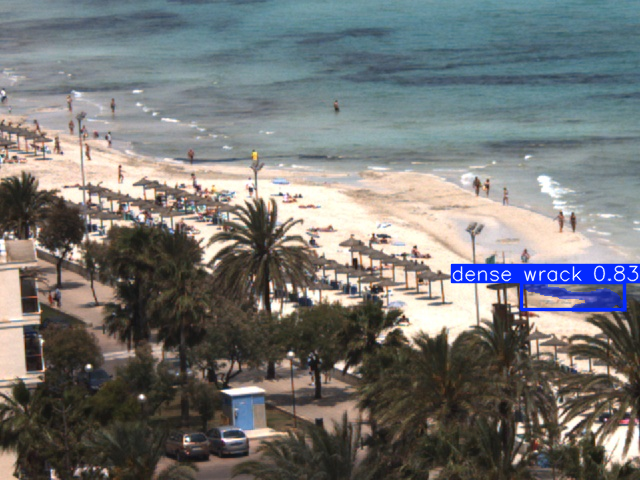

In [ ]:
# --- 4. Read and Encode the Image ---
MEDIA_PATH = "path/to/your/test_image.jpg"  # Update this to the path of your test image
img = cv2.imread(MEDIA_PATH)

if img is None:
    print(f"❌ Error: Could not load image at {MEDIA_PATH}. Please check the path.")
else:
    # Encode the image to JPEG format in memory
    success, encoded_img = cv2.imencode('.jpg', img)
    
    if not success:
        print("❌ Error: Failed to encode the image.")
    else:
        # Convert the encoded image to raw bytes
        image_bytes = encoded_img.tobytes()
        
        # Prepare the files dictionary mapping to the "files" field in the schema
        files = {
            "files": ("input_frame.jpg", image_bytes, "image/jpeg")
        }
        
        print("📤 Sending fully parameterized request to the API...")
        
        # --- 5. Make the POST Request ---
        # We pass the inference parameters via the 'data' argument (form-data)
        response = requests.post(
            API_URL, 
            headers=headers, 
            data=payload, 
            files=files
        )
        
        # --- 6. Handle the Response ---
        if response.status_code == 200:
            print("✅ Request successful!\n")
            
            # If we requested JSON:
            if headers["accept"] == "application/json":
                try:
                    result_json = response.json()
                    print(json.dumps(result_json, indent=4))
                except json.JSONDecodeError:
                    print("Could not parse JSON response.")
            
            # If we requested an Image (e.g., image/png):
            elif headers["accept"] in ["image/png", "image/jpeg"]:
                display(Image(data=response.content))
                
        else:
            print(f"❌ Request failed with status code: {response.status_code}")
            print("Response text:", response.text)